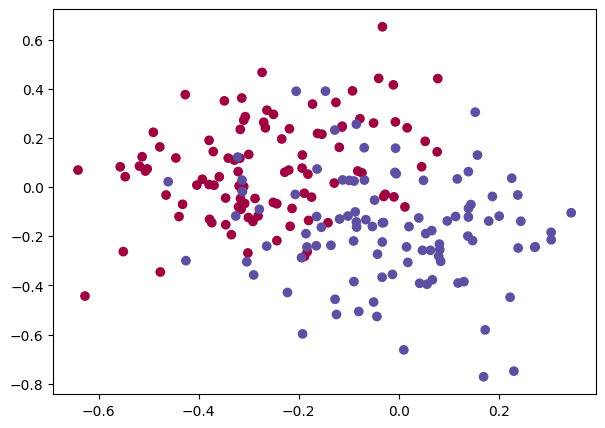

In [262]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(3)

m = 200

# Blue class
X0 = np.random.multivariate_normal(
    mean=[-0.25, 0.10],
    cov=[[0.025, 0.010],
         [0.010, 0.045]],
    size=m//2
)

# Red class
X1 = np.random.multivariate_normal(
    mean=[0.00, -0.20],
    cov=[[0.025, -0.010],
         [-0.010, 0.045]],
    size=m//2
)

X = np.vstack((X0, X1))
Y = np.hstack((np.zeros(m//2), np.ones(m//2)))

# Convert to Coursera format
X = X.T
Y = Y.reshape(1,-1)

plt.figure(figsize=(7,5))
plt.scatter(
    X[0,:],
    X[1,:],
    c=Y.flatten(),
    cmap=plt.cm.Spectral
)
plt.show()

In [263]:
layers_dims = [X.shape[0], 20, 3, 1]

In [264]:
#initialize parameters with random values
def initialize_parameters(layers_dims):
    np.random.seed(1)
    parameters = {}
    L = len(layers_dims)
    for l in range(1,L):
        parameters['W'+str(l)] = np.random.randn(layers_dims[l], layers_dims[l-1]) * 1.0
        parameters["b" + str(l)] = np.zeros(
            (layers_dims[l], 1)
        )
    return parameters

In [265]:
#Activation functions
def relu(Z):
    return np.maximum(0, Z)

def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

In [266]:
#Forward propagation
def forward_propagation(X, parameters):

    W1 = parameters["W1"]
    b1 = parameters["b1"]

    W2 = parameters["W2"]
    b2 = parameters["b2"]

    W3 = parameters["W3"]
    b3 = parameters["b3"]

    # Layer 1
    Z1 = np.dot(W1, X) + b1
    A1 = relu(Z1)

    # Layer 2
    Z2 = np.dot(W2, A1) + b2
    A2 = relu(Z2)

    # Output layer
    Z3 = np.dot(W3, A2) + b3
    A3 = sigmoid(Z3)

    cache = (
        Z1, A1, W1, b1,
        Z2, A2, W2, b2,
        Z3, A3, W3, b3
    )

    return A3, cache

In [267]:
def compute_loss(A3, Y):

    m = Y.shape[1]

    A3 = np.clip(A3, 1e-15, 1 - 1e-15)

    loss = -(1/m) * np.sum(
        Y * np.log(A3)
        +
        (1-Y) * np.log(1-A3)
    )

    return np.squeeze(loss)

In [268]:
#Backward propagation
def backward_propagation(X, Y, cache):

    m = X.shape[1]

    (
        Z1, A1, W1, b1,
        Z2, A2, W2, b2,
        Z3, A3, W3, b3
    ) = cache

    dZ3 = A3 - Y

    dW3 = (1/m) * np.dot(dZ3, A2.T)
    db3 = (1/m) * np.sum(
        dZ3,
        axis=1,
        keepdims=True
    )

    dA2 = np.dot(W3.T, dZ3)

    dZ2 = dA2 * (A2 > 0)

    dW2 = (1/m) * np.dot(dZ2, A1.T)

    db2 = (1/m) * np.sum(
        dZ2,
        axis=1,
        keepdims=True
    )

    dA1 = np.dot(W2.T, dZ2)

    dZ1 = dA1 * (A1 > 0)

    dW1 = (1/m) * np.dot(dZ1, X.T)

    db1 = (1/m) * np.sum(
        dZ1,
        axis=1,
        keepdims=True
    )

    gradients = {

        "dW1": dW1,
        "db1": db1,

        "dW2": dW2,
        "db2": db2,

        "dW3": dW3,
        "db3": db3
    }

    return gradients

In [269]:
#Update parameters
def update_parameters(parameters,
                      grads,
                      learning_rate):

    L = len(parameters) // 2

    for l in range(1, L + 1):

        parameters["W" + str(l)] -= (
            learning_rate
            * grads["dW" + str(l)]
        )

        parameters["b" + str(l)] -= (
            learning_rate
            * grads["db" + str(l)]
        )

    return parameters

In [270]:
def model(X, Y, learning_rate = 0.3, num_iterations = 30000, print_cost = True, lambd = 0, keep_prob = 1):
        
    grads = {}
    costs = []                            # to keep track of the cost
    m = X.shape[1]                        # number of examples
    layers_dims = [X.shape[0], 20, 3, 1]
    
    # Initialize parameters dictionary.
    parameters = initialize_parameters(layers_dims)

    # Loop (gradient descent)

    for i in range(0, num_iterations):

        # Forward propagation: LINEAR -> RELU -> LINEAR -> RELU -> LINEAR -> SIGMOID.
        if keep_prob == 1:
            a3, cache = forward_propagation(X, parameters)
        elif keep_prob < 1:
            a3, cache = forward_propagation_with_dropout(X, parameters, keep_prob)
        
        # Cost function
        if lambd == 0:
            cost = compute_loss(a3, Y)
        else:
            cost = compute_loss_with_regularization(a3, Y, parameters, lambd)
            
        # Backward propagation.
        assert (lambd == 0 or keep_prob == 1)   # it is possible to use both L2 regularization and dropout, 
                                                # but this assignment will only explore one at a time
        if lambd == 0 and keep_prob == 1:
            grads = backward_propagation(X, Y, cache)
        elif lambd != 0:
            grads = backward_propagation_with_regularization(X, Y, cache, lambd)
        elif keep_prob < 1:
            grads = backward_propagation_with_dropout(X, Y, cache, keep_prob)
        
        # Update parameters.
        parameters = update_parameters(parameters, grads, learning_rate)
        
        # Print the loss every 10000 iterations
        if print_cost and i % 10000 == 0:
            print("Cost after iteration {}: {}".format(i, cost))
        if print_cost and i % 1000 == 0:
            costs.append(cost)
    
    # plot the cost
    plt.plot(costs)
    plt.ylabel('cost')
    plt.xlabel('iterations (x1,000)')
    plt.title("Learning rate =" + str(learning_rate))
    plt.show()
    
    return parameters

In [271]:
def predict(X, Y, parameters):

    A3, _ = forward_propagation(X, parameters)

    predictions = (A3 > 0.5).astype(int)

    accuracy = np.mean(predictions == Y) * 100

    print("Accuracy: {:.2f}%".format(accuracy))

    return predictions

In [272]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X.T,
    Y.flatten(),
    test_size=0.2,
    random_state=42
)

X_train = X_train.T
X_test = X_test.T

Y_train = Y_train.reshape(1, -1)
Y_test = Y_test.reshape(1, -1)

Cost after iteration 0: 0.555753959151092
Cost after iteration 10000: 0.24813103311162854
Cost after iteration 20000: 0.2378746362497192


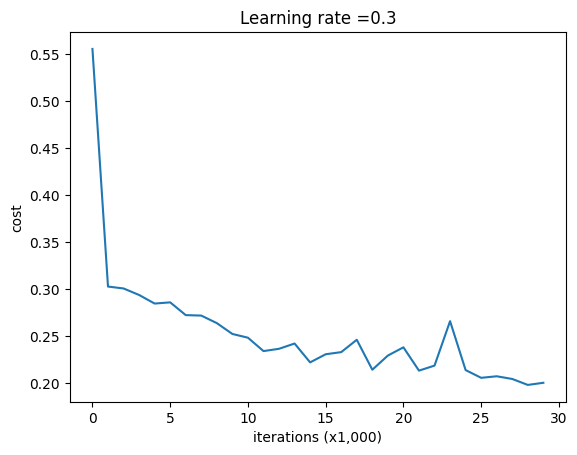

In [273]:
parameters = model(
    X_train,
    Y_train,
    print_cost=True
)

Cost after iteration 0: 0.555753959151092
Cost after iteration 10000: 0.24813103311162854
Cost after iteration 20000: 0.2378746362497192


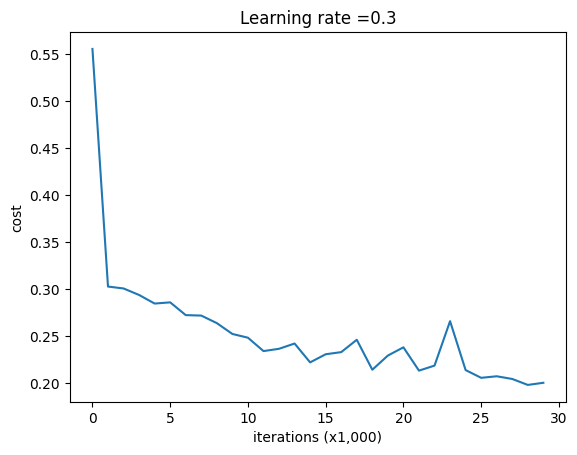

On the training set:
Accuracy: 91.88%
On the test set:
Accuracy: 77.50%


In [274]:
# pred_train = predict(X_train, parameters)

# accuracy = np.mean(pred_train == Y_train) * 100

# print(f"Train Accuracy: {accuracy:.2f}%")

parameters = model(X_train, Y_train)
print ("On the training set:")
predictions_train = predict(X_train, Y_train, parameters)
print ("On the test set:")
predictions_test = predict(X_test, Y_test, parameters)

In [275]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(model, X, Y):

    x_min, x_max = X[0, :].min() - 1, X[0, :].max() + 1
    y_min, y_max = X[1, :].min() - 1, X[1, :].max() + 1

    h = 0.01

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = model(grid)

    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8,6))

    plt.contourf(
        xx,
        yy,
        Z,
        cmap=plt.cm.Spectral,
        alpha=0.5
    )

    plt.scatter(
        X[0,:],
        X[1,:],
        c=Y.flatten(),
        cmap=plt.cm.Spectral,
        edgecolors="k"
    )

    plt.xlabel("X1")
    plt.ylabel("X2")

    plt.show()

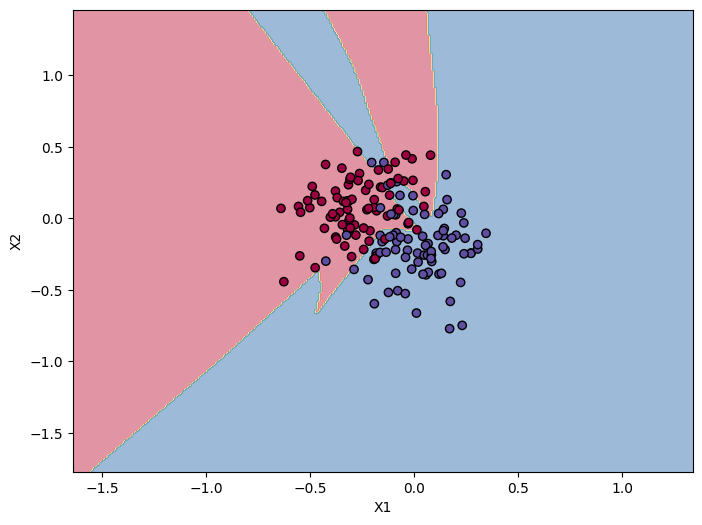

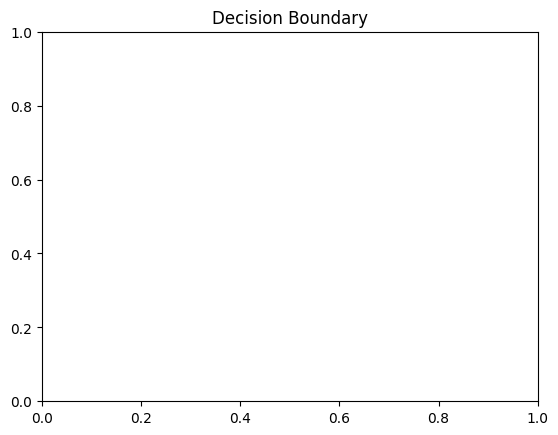

In [276]:
plot_decision_boundary(
    lambda x: predict_decision(parameters, x),
    X_train,
    Y_train
)

plt.title("Decision Boundary")
plt.show()

In [277]:
# GRADED FUNCTION: compute_cost_with_regularization

def compute_cost_with_regularization(A3, Y, parameters, lambd):
    
    m = Y.shape[1]
    W1 = parameters["W1"]
    W2 = parameters["W2"]
    W3 = parameters["W3"]
    
    cross_entropy_cost = compute_cost(A3, Y) # This gives you the cross-entropy part of the cost
    
    L2_regularization_cost = (lambd/(2*m)) * (
    np.sum(np.square(W1))
    + np.sum(np.square(W2))
    + np.sum(np.square(W3))
    )
   
    cost = cross_entropy_cost + L2_regularization_cost
    
    return cost

In [278]:
# GRADED FUNCTION: backward_propagation_with_regularization

def backward_propagation_with_regularization(X, Y, cache, lambd):
    
    m = X.shape[1]
    (Z1, A1, W1, b1, Z2, A2, W2, b2, Z3, A3, W3, b3) = cache
    
    dZ3 = A3 - Y
    dW3 = 1/m * np.dot(dZ3, A2.T) +  (lambd / m) * W3
    
    db3 = 1. / m * np.sum(dZ3, axis=1, keepdims=True)
    
    dA2 = np.dot(W3.T, dZ3)
    dZ2 = np.multiply(dA2, np.int64(A2 > 0))
    
    dW2 = (1/m) * np.dot(dZ2, A1.T) + (lambd/m) * W2
    db2 = 1. / m * np.sum(dZ2, axis=1, keepdims=True)
    
    dA1 = np.dot(W2.T, dZ2)
    dZ1 = np.multiply(dA1, np.int64(A1 > 0))
    dW1 = (1/m) * np.dot(dZ1, X.T) + (lambd/m) * W1
    
    db1 = 1. / m * np.sum(dZ1, axis=1, keepdims=True)
    
    gradients = {"dZ3": dZ3, "dW3": dW3, "db3": db3,"dA2": dA2,
                 "dZ2": dZ2, "dW2": dW2, "db2": db2, "dA1": dA1, 
                 "dZ1": dZ1, "dW1": dW1, "db1": db1}
    
    return gradients

Cost after iteration 0: 0.555753959151092
Cost after iteration 10000: 0.32516166930492296
Cost after iteration 20000: 0.3244619462258188


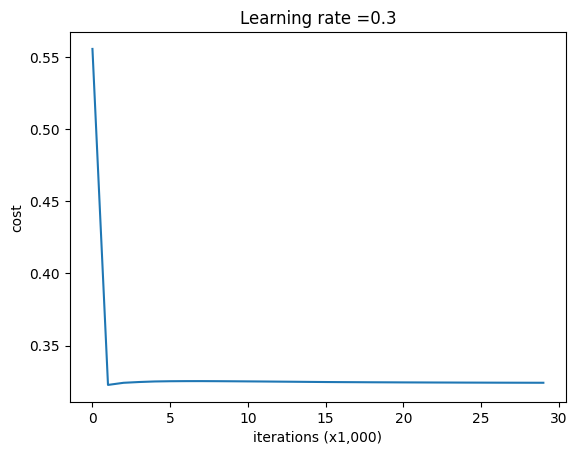

On the train set:
Accuracy: 86.25%
On the test set:
Accuracy: 77.50%


In [279]:
parameters = model(X_train, Y_train, lambd = 0.7)
print ("On the train set:")
predictions_train = predict(X_train, Y_train, parameters)
print ("On the test set:")
predictions_test = predict(X_test, Y_test, parameters)

In [280]:
def predict_decision(parameters, X):
  
    A3, _ = forward_propagation(X.T, parameters)

    predictions = (A3 > 0.5).astype(int)

    return predictions.reshape(-1)

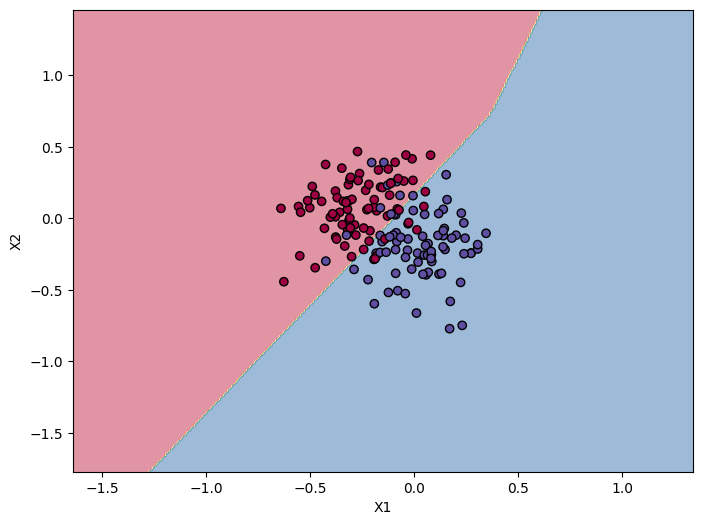

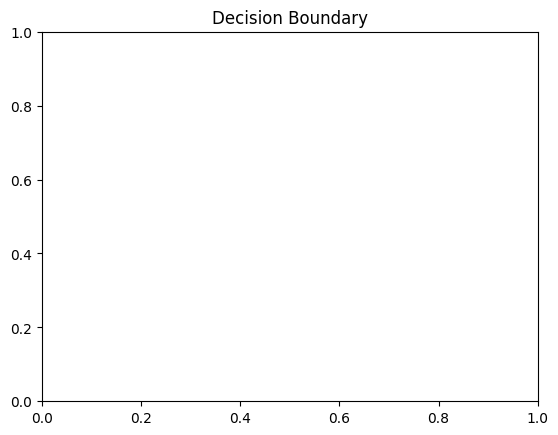

In [281]:
plot_decision_boundary(
    lambda x: predict_decision(parameters, x),
    X_train,
    Y_train
)

plt.title("Decision Boundary")
plt.show()

In [282]:
# GRADED FUNCTION: forward_propagation_with_dropout

def forward_propagation_with_dropout(X, parameters, keep_prob = 0.5):
    
    np.random.seed(1)
    
    # retrieve parameters
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    W3 = parameters["W3"]
    b3 = parameters["b3"]
    
    Z1 = np.dot(W1, X) + b1
    A1 = relu(Z1)
    
    D1 = np.random.rand(A1.shape[0], A1.shape[1])
    D1 = (D1 < keep_prob)
    A1 = A1 * D1
    A1 = A1 / keep_prob
    
    Z2 = np.dot(W2, A1) + b2
    A2 = relu(Z2)
    
    D2 = np.random.rand(A2.shape[0], A2.shape[1])
    D2 = (D2 < keep_prob)
    A2 = A2 * D2
    A2 = A2 / keep_prob
    
    Z3 = np.dot(W3, A2) + b3
    A3 = sigmoid(Z3)
    
    cache = (Z1, D1, A1, W1, b1, Z2, D2, A2, W2, b2, Z3, A3, W3, b3)
    
    return A3, cache

In [283]:
# GRADED FUNCTION: backward_propagation_with_dropout

def backward_propagation_with_dropout(X, Y, cache, keep_prob):
   
    m = X.shape[1]
    (Z1, D1, A1, W1, b1, Z2, D2, A2, W2, b2, Z3, A3, W3, b3) = cache
    
    dZ3 = A3 - Y
    dW3 = 1./m * np.dot(dZ3, A2.T)
    db3 = 1./m * np.sum(dZ3, axis=1, keepdims=True)
    dA2 = np.dot(W3.T, dZ3)

    dA2 = dA2 * D2
    dA2 = dA2 / keep_prob

    dZ2 = np.multiply(dA2, np.int64(A2 > 0))
    dW2 = 1./m * np.dot(dZ2, A1.T)
    db2 = 1./m * np.sum(dZ2, axis=1, keepdims=True)
    
    dA1 = np.dot(W2.T, dZ2)

    dA1 = dA1 * D1
    dA1 = dA1 / keep_prob    

    dZ1 = np.multiply(dA1, np.int64(A1 > 0))
    dW1 = 1./m * np.dot(dZ1, X.T)
    db1 = 1./m * np.sum(dZ1, axis=1, keepdims=True)
    
    gradients = {"dZ3": dZ3, "dW3": dW3, "db3": db3,"dA2": dA2,
                 "dZ2": dZ2, "dW2": dW2, "db2": db2, "dA1": dA1, 
                 "dZ1": dZ1, "dW1": dW1, "db1": db1}
    
    return gradients

Cost after iteration 0: 0.602280538168483
Cost after iteration 10000: 0.04373608078692993
Cost after iteration 20000: 0.21273046585082014


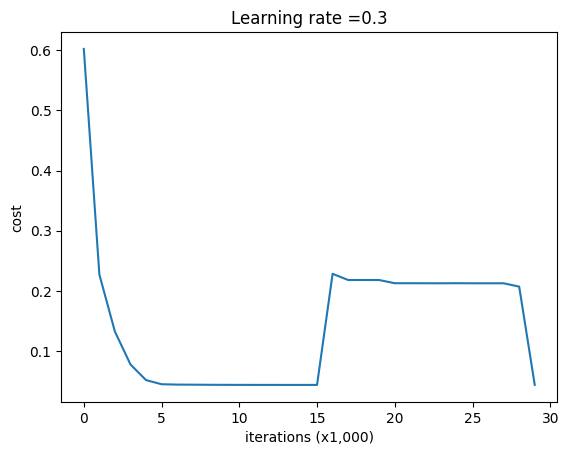

On the train set:
Accuracy: 85.62%
On the test set:
Accuracy: 80.00%


In [284]:
parameters = model(X_train, Y_train, keep_prob = 0.86, learning_rate = 0.3)

print ("On the train set:")
predictions_train = predict(X_train, Y_train, parameters)
print ("On the test set:")
predictions_test = predict(X_test, Y_test, parameters)

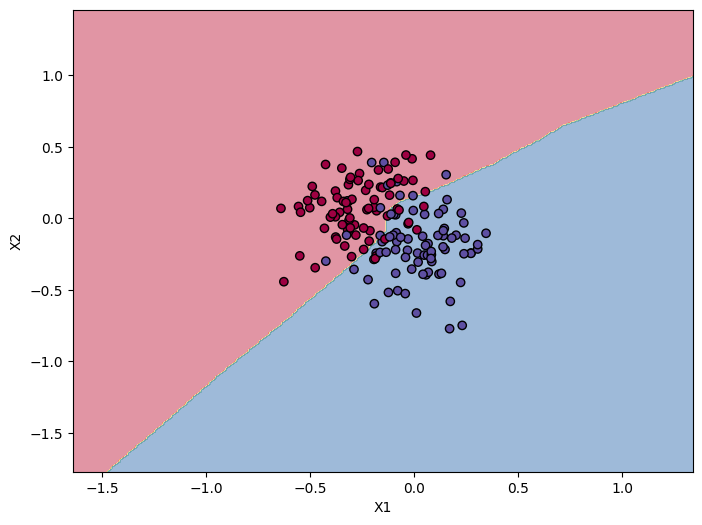

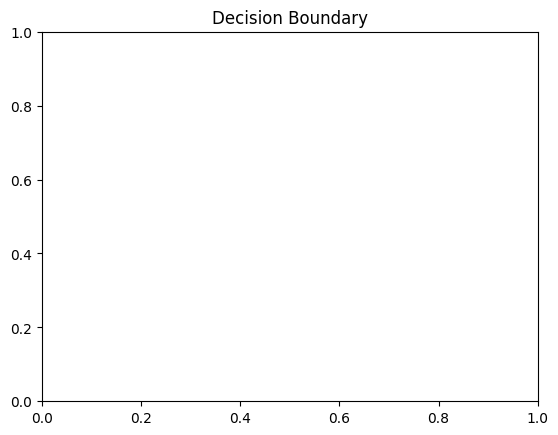

In [285]:
plot_decision_boundary(
    lambda x: predict_decision(parameters, x),
    X_train,
    Y_train
)

plt.title("Decision Boundary")
plt.show()

Conclusion:

Model without regularization: Overfitting
- On the training set:
  Accuracy: 91.88%
- On the test set:
  Accuracy: 77.50%

Model with L2 regularization: Less overfitting
- On the train set:
  Accuracy: 86.25%
- On the test set:
  Accuracy: 77.50%

Model with dropout regularization: Better generalization
- On the train set:
  Accuracy: 85.62%
- On the test set:
  Accuracy: 80.00%